In [ ]:
"""Some plotting/analysis code for understanding force norms and cosine similarities"""
        # all_norms = []
        # all_cosine_sims = []
        # ref_time = {
        #     "chignolin": 20,
        #     "bba": 5,
        #     "trp_cage": 15,
        #     "villin": 5,
        #     "protein_g": 5,
        # }
        # model = load_mlff_model(
        #     f"mlffs/{self.protein}/model.ckpt",
        #     derivative=True,
        # ).to(self.device)
        # residue_nums = np.load(
        #     f"datasets/mlff_residue_numbers/{self.protein}_ca_embeddings.npy"
        # )
        # residue_nums = torch.tensor(np.array([int(i) for i in residue_nums])).to(
        #     self.device
        # )

        # def get_force_from_mlff(x):
        #     batch = (
        #         torch.arange(x.shape[0]).repeat_interleave(self.num_atoms).to(x.device)
        #     )
        #     z = residue_nums.repeat(x.shape[0])
        #     x = x.reshape(-1, 3) * self.norm_factor
        #     force = model(z=z, pos=x, batch=batch)[1].reshape(-1, self.num_atoms, 3)
        #     return force

        # ref_force = get_force_from_mlff(all_noised_xs[0][0])
        # force = self.force_func(
        #     center_zero(all_noised_xs[0][0]), ref_time[self.protein]
        # )
        # ref_force_norms = torch.norm(ref_force, dim=-1).mean(-1)
        # force_norms = torch.norm(force, dim=-1).mean(-1)

        # # plot this
        # import matplotlib.pyplot as plt

        # plt.plot(
        #     ref_force_norms.detach().cpu().numpy(), label="Reference MLFF Force Norm"
        # )
        # plt.plot(force_norms.detach().cpu().numpy(), label="Diffusion Force Norm")
        # plt.ylabel("Force Norm")
        # plt.xlabel("Path Step")
        # plt.legend()
        # plt.title(self.protein)
        # plt.show()
        # # save the figure
        # plt.savefig(f"mlff_force_norms_{self.protein}.png")
        # plt.close()

        # import pdb

        # pdb.set_trace()
        # with torch.no_grad():
        #     for t in tqdm(range(self.num_timesteps)):
        #         force = self.force_func(center_zero(all_noised_xs[0][0]), t)
        #         cosine_sim = F.cosine_similarity(force, ref_force, dim=-1).mean(dim=-1)
        #         all_cosine_sims.append(cosine_sim)
        #         norms = (
        #             torch.norm(force, dim=-1) / torch.norm(ref_force, dim=-1)
        #         ).mean(dim=-1)
        #         all_norms.append(norms)

        # import matplotlib.pyplot as plt

        # all_norms = torch.stack(all_norms).T
        # all_cosine_sims = torch.stack(all_cosine_sims).T
        # # all_norms has shape [path_length, T]
        # # for each path, plot the norm of the force as a function of time
        # for i in range(int(all_norms.shape[0] / 2) + 1):
        #     if i % 20 != 0:
        #         continue
        #     weighting = i / all_norms.shape[0]
        #     plt.plot(
        #         all_norms[i].cpu().numpy(),
        #         label=f"Linear Interpolation Weight {round(weighting, 2)}",
        #     )
        # plt.legend(loc="upper right")
        # plt.yscale("log")
        # plt.xlabel("Diffusion Timestep")
        # plt.ylabel("Norm Ratio of Denoising Model Output w.r.t Reference MLFF Force")
        # plt.title(self.protein)
        # plt.show()

        # # save the figure
        # plt.savefig(f"ratio_force_norms_{self.protein}.png")
        # plt.close()

        # for i in range(int(all_cosine_sims.shape[0] / 2) + 1):
        #     if i % 20 != 0:
        #         continue
        #     weighting = i / all_norms.shape[0]
        #     plt.plot(
        #         all_cosine_sims[i].cpu().numpy(),
        #         label=f"Linear Interpolation Weight {round(weighting, 2)}",
        #     )
        # plt.legend(loc="upper right")
        # # plt.yscale("log")
        # plt.xlabel("Diffusion Timestep")
        # plt.ylabel(
        #     "Cosine Similarity of Denoising Model Output to Reference MLFF Force"
        # )
        # # plt.axvline(x=ref_time[self.protein], color="red", linestyle="--", label="Reference Time")
        # plt.title(self.protein)
        # plt.show()

        # # save the figure
        # plt.savefig(f"mlff_cosine_sims_{self.protein}.png")
        """End of plotting/analysis code"""

(-100000.0, 1000.0)

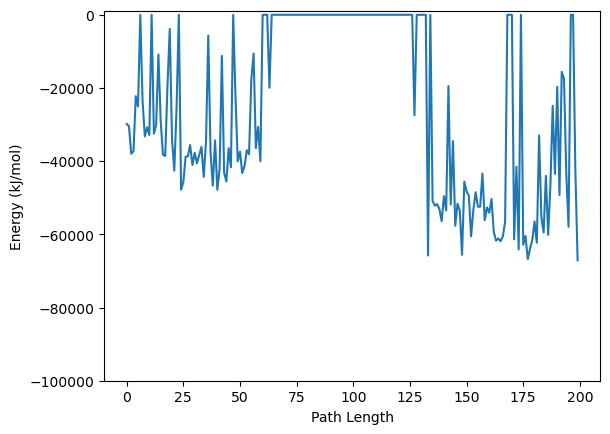

In [16]:
import numpy as np
import torch
import matplotlib.pyplot as plt


energies = np.clip(np.load("energies.npy"), -10**5, 10**0)
plt.figure()

plt.plot(energies)
plt.xlabel("Path Length")
plt.ylabel("Energy (kJ/mol)")
# plt.yscale("log")
plt.ylim(-10**5, 10**3)



In [1]:
import os
import torch
import mdtraj as md
import numpy as np
from tqdm import tqdm
from pathlib import Path
from datasets.dataset_utils_empty import Molecules, DEShawDataset, AtomSelection, to_angstrom, norm_stds
from models.graph_transformer import GraphTransformer
from evaluate.evaluators import TicEvaluator
from evaluate.evaluate_fastfolders import CLUSTER_ENDPOINTS
from evaluate.msm_utils import discretize_trajectory
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = torch.device(torch.cuda.current_device())
protein_name = "trp_cage"

gen_mode = "langevin" # Mode of generation, "iid" or "langevin"
subsample = None # Give integer if only a random subset of the samples should be analyzed (if None, all samples are used)
append_exp_name = None # Append string to the experiment name"
append_exp_name_str = '_' + append_exp_name if append_exp_name else ''
eval_folder = f"./saved_models/{protein_name}/main_eval_output_{gen_mode}{append_exp_name_str}"

# Load samples from the ground truth simulations to serve as training data
dataset = DEShawDataset(
    data_root="/data/sanjeevr/Reference_MD_Sims",
    molecule=Molecules[protein_name.upper()],
    simulation_id=0,
    atom_selection=AtomSelection.PROTEIN,
    return_bond_graph=False,
    transform=to_angstrom,
    align=False,
)


gt_traj = 10 * torch.tensor(dataset.traj.xyz)  # convert to angstroms
gt_traj -= gt_traj.mean(1, keepdims=True)  # center

n_atoms = gt_traj.shape[1]


/home/sanjeevr/miniforge3/envs/om-diffusion/lib/python3.12/site-packages/mdtraj/formats/pdb/pdbfile.py:206: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(


In [5]:
# Save ground truth traj to ovito
from logging_utils import save_ovito_traj
topology = md.load("/data/sanjeevr/Reference_MD_Sims/2JOF/simulation_0/protein/2JOF-0-protein/2JOF-0-protein.pdb").topology
all_mol_traj = md.Trajectory(gt_traj[0:100000].numpy() / 10, topology=topology)
all_mol_traj.save_pdb(f"trp_cage_gt.pdb")

In [7]:
all_mol_traj = md.Trajectory(gt_traj[0].numpy() / 10, topology=topology)
all_mol_traj.save_pdb(f"trp_cage_folded.pdb")